# Verification: Kinetic Proofreading (Hlavacek et al., 2001)

This notebook independently verifies two BNGL model files against the
ODEs from Hlavacek et al. (2001, 2002):

1. **Base model** (`kinetic_proofreading_hlavacek2001.bngl`) — bivalent
   ligand + monovalent receptor binding, dimer formation, and sequential
   modification (N=5). Verified against Eq. 1–7 of Hlavacek et al. (2002).

2. **Messenger variant** (`kinetic_proofreading_hlavacek2001_messenger.bngl`)
   — adds enzymatic activation of a cytosolic messenger by terminally
   modified dimers. Verified against Eq. 8–10 of Hlavacek et al. (2002).
   The BNGL model uses a fast-release rule (`k_release = 1000/s`) to
   approximate instantaneous messenger ejection on dimer dissociation;
   the independent ODE uses exact instantaneous release, so small
   discrepancies are expected.

### References

- Hlavacek WS et al. (2001). *PNAS* 98:7295–7300.
- Hlavacek WS et al. (2002). *Bull Math Biol* 64:887–911.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import subprocess, pathlib, os

MODEL_DIR = pathlib.Path(".").resolve()
BASE_BNGL = MODEL_DIR / "kinetic_proofreading_hlavacek2001.bngl"
MSG_BNGL = MODEL_DIR / "kinetic_proofreading_hlavacek2001_messenger.bngl"

def run_bng(bngl_path, out_dir):
    """Run a BNGL file via bionetgen and return the output directory."""
    out = pathlib.Path(out_dir)
    out.mkdir(exist_ok=True)
    subprocess.run(
        ["bionetgen", "run", "-i", str(bngl_path), "-o", str(out)],
        cwd="/tmp", check=True, capture_output=True,
    )
    return out

def load_gdat(path):
    """Load a .gdat file, return (header_list, 2-d array)."""
    with open(path) as f:
        header = f.readline().strip().lstrip("#").split()
    data = np.loadtxt(path, comments="#")
    return header, data

## 1. Shared parameters

In [2]:
# Parameters matching the BNGL files (Table 1, Hlavacek et al. 2002)
NR = 300_000        # receptors / cell
NL = 602            # ligand molecules / cell (1 nM)
kon1 = 1.661e-8     # /(molecule*s)  ligand capture
kon2 = 3.333e-6     # /(molecule*s)  crosslinking
koff = 0.1          # /s             dissociation (k-1 = k-2)
kp = 0.4            # /s             modification
N = 5               # modification steps

# Messenger parameters (variant model only)
NX = 10_000         # messenger molecules / cell
kx_on = 1.2e-4      # /(molecule*s)  messenger binding to D5
kx_off = 0.01       # /s             messenger unbinding
kcat = 1.0          # /s             catalytic activation
mu = 0.01           # /s             messenger inactivation

# Proofreading parameter
alpha = kp / (kp + 2 * koff)
print(f"alpha = {alpha:.4f},  alpha^{N} = {alpha**N:.4f}")

alpha = 0.6667,  alpha^5 = 0.1317


## 2. Base model — independent ODE (Eq. 1–7)

State vector: `[L, B, R, D0, D1, D2, D3, D4, D5]`

- `L` = free ligand, `B` = singly-bound ligand, `R` = free receptor
- `Di` = dimers modified *i* times

BioNetGen applies a statistical factor of 2 for the two equivalent `r`
sites on `L`, so the binding flux is `2·kon1·L·R`. Each dimer has two
bonds that can break at rate `koff`, giving `2·koff` per dimer.

In [3]:
def base_ode(t, y):
    """RHS for the base kinetic proofreading model (Eq. 1-7)."""
    L, B, R = y[0], y[1], y[2]
    D = y[3:9]          # D[0]..D[5]
    D_total = D.sum()

    dydt = np.zeros(9)

    # Binding (Eq. 1-4 in Hlavacek et al. 2002)
    bind = 2 * kon1 * L * R          # ligand capture flux
    unbind_B = koff * B               # singly-bound dissociation
    xlink = kon2 * B * R              # crosslinking flux
    dimer_dissoc = 2 * koff * D_total # total dimer dissociation flux

    dydt[0] = -bind + unbind_B                          # dL/dt
    dydt[1] = bind - unbind_B - xlink + dimer_dissoc    # dB/dt
    dydt[2] = -bind + unbind_B - xlink + dimer_dissoc   # dR/dt

    # Dimer modification (Eq. 5-7)
    dydt[3] = xlink - 2*koff*D[0] - kp*D[0]            # dD0/dt
    for i in range(1, N):
        dydt[3+i] = kp*D[i-1] - 2*koff*D[i] - kp*D[i] # dDi/dt
    dydt[3+N] = kp*D[N-1] - 2*koff*D[N]                # dDN/dt

    return dydt

# Initial conditions: all free
y0_base = np.zeros(9)
y0_base[0] = NL   # free ligand
y0_base[2] = NR   # free receptor

# Solve
t_end = 600
sol_base = solve_ivp(base_ode, [0, t_end], y0_base,
                     method="BDF", rtol=1e-10, atol=1e-10,
                     dense_output=True,
                     t_eval=np.linspace(0, t_end, 301))
print(f"SciPy solver status: {sol_base.message}")
print(f"Final L={sol_base.y[0,-1]:.2f}, B={sol_base.y[1,-1]:.2f}, "
      f"R={sol_base.y[2,-1]:.0f}")
print(f"Final D_total={sol_base.y[3:9,-1].sum():.2f}, "
      f"D5={sol_base.y[8,-1]:.2f}")
print(f"D5/D_total = {sol_base.y[8,-1]/sol_base.y[3:9,-1].sum():.4f} "
      f"(theory alpha^5 = {alpha**5:.4f})")

SciPy solver status: The solver successfully reached the end of the integration interval.
Final L=377.10, B=37.53, R=299588
Final D_total=187.37, D5=24.67
D5/D_total = 0.1317 (theory alpha^5 = 0.1317)


### 2a. Run BNG base model and compare

In [4]:
# Run BNG
base_out = run_bng(BASE_BNGL, "/tmp/verify_base")
hdr, bng = load_gdat(
    base_out / "kinetic_proofreading_hlavacek2001_ode.gdat")
print("BNG columns:", hdr)

# Extract BNG trajectories
t_bng = bng[:, 0]
bng_free_L   = bng[:, hdr.index("Obs_Free_L")]
bng_free_R   = bng[:, hdr.index("Obs_Free_R")]
bng_dimers   = bng[:, hdr.index("Obs_Tot_Dimers")]
bng_D5       = bng[:, hdr.index("Obs_D5")]
bng_singly   = bng[:, hdr.index("Obs_Singly_Bound")]

# Interpolate SciPy solution at BNG time points
sci = sol_base.sol(t_bng)
sci_free_L = sci[0]
sci_singly = sci[1]
sci_free_R = sci[2]
sci_dimers = sci[3:9].sum(axis=0)
sci_D5     = sci[8]

# Compute max relative errors (using max value as scale)
def max_rel_err(a, b, name):
    scale = max(np.max(np.abs(a)), np.max(np.abs(b)), 1e-30)
    err = np.max(np.abs(a - b)) / scale
    print(f"  {name:20s}  max|err|/scale = {err:.2e}")
    return err

print("\nMax relative errors (base model):")
errs_base = []
errs_base.append(max_rel_err(bng_free_L, sci_free_L, "Free_L"))
errs_base.append(max_rel_err(bng_free_R, sci_free_R, "Free_R"))
errs_base.append(max_rel_err(bng_singly, sci_singly, "Singly_Bound"))
errs_base.append(max_rel_err(bng_dimers, sci_dimers, "Tot_Dimers"))
errs_base.append(max_rel_err(bng_D5, sci_D5, "D5"))
print(f"\n  Overall max relative error: {max(errs_base):.2e}")

BNG columns: ['time', 'Obs_Free_L', 'Obs_Free_R', 'Obs_Singly_Bound', 'Obs_Tot_Dimers', 'Obs_D0', 'Obs_D1', 'Obs_D2', 'Obs_D3', 'Obs_D4', 'Obs_D5']

Max relative errors (base model):
  Free_L                max|err|/scale = 8.12e-09
  Free_R                max|err|/scale = 3.01e-11
  Singly_Bound          max|err|/scale = 1.95e-08
  Tot_Dimers            max|err|/scale = 2.23e-08
  D5                    max|err|/scale = 2.75e-08

  Overall max relative error: 2.75e-08


### 2b. Base model overlay plots

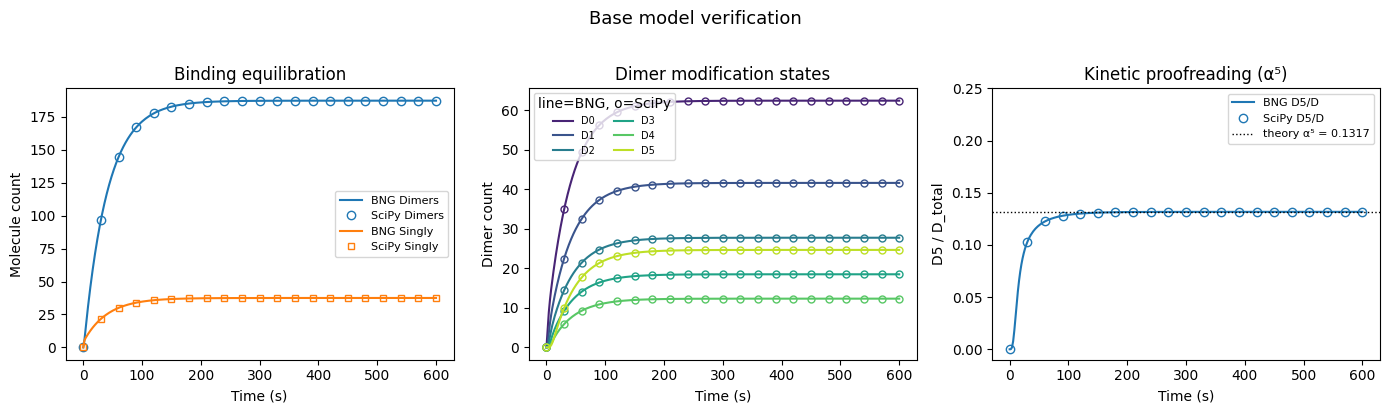

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Subsampling for SciPy markers (every 15th point)
every = 15

# Panel 1: binding equilibration
ax = axes[0]
ax.plot(t_bng, bng_dimers, "C0-", lw=1.5, label="BNG Dimers")
ax.plot(t_bng[::every], sci_dimers[::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy Dimers")
ax.plot(t_bng, bng_singly, "C1-", lw=1.5, label="BNG Singly")
ax.plot(t_bng[::every], sci_singly[::every], "s", mfc="none",
        mec="C1", ms=5, label="SciPy Singly")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Molecule count")
ax.set_title("Binding equilibration")
ax.legend(fontsize=8)

# Panel 2: modification states (D0-D5)
ax = axes[1]
colors_d = plt.cm.viridis(np.linspace(0.1, 0.9, 6))
for i in range(6):
    bng_Di = bng[:, hdr.index(f"Obs_D{i}")]
    sci_Di = sci[3 + i]
    ax.plot(t_bng, bng_Di, "-", color=colors_d[i], lw=1.5,
            label=f"D{i}")
    ax.plot(t_bng[::every], sci_Di[::every], "o", mfc="none",
            mec=colors_d[i], ms=5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Dimer count")
ax.set_title("Dimer modification states")
ax.legend(fontsize=7, ncol=2, title="line=BNG, o=SciPy")

# Panel 3: D5/D_total vs time and alpha^5 reference
ax = axes[2]
frac_bng = bng_D5 / np.maximum(bng_dimers, 1e-30)
frac_sci = sci_D5 / np.maximum(sci_dimers, 1e-30)
ax.plot(t_bng, frac_bng, "C0-", lw=1.5, label="BNG D5/D")
ax.plot(t_bng[::every], frac_sci[::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy D5/D")
ax.axhline(alpha**N, color="k", ls=":", lw=1,
           label=f"theory α⁵ = {alpha**N:.4f}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("D5 / D_total")
ax.set_title("Kinetic proofreading (α⁵)")
ax.set_ylim(-0.01, 0.25)
ax.legend(fontsize=8)

fig.suptitle("Base model verification", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 3. Messenger variant — independent ODE (Eq. 1–10)

Extends the base ODE with messenger activation (Eq. 8–10). The
independent ODE uses **exact instantaneous release**: when a D5-bound
dimer dissociates, the messenger is returned to the inactive pool
immediately. The BNGL model approximates this with `k_release = 1000/s`.

State vector: `[L, B, R, D0, ..., D4, D5_free, D5_bound, X_off, X_on]`
(12 variables).

In [6]:
def messenger_ode(t, y):
    """RHS for kinetic proofreading + messenger (Eq. 1-10).

    State: [L, B, R, D0, D1, D2, D3, D4, D5_free, D5_bound, X_off, X_on]
    Instantaneous messenger release on dimer dissociation.
    """
    L, B, R = y[0], y[1], y[2]
    D = y[3:8]                # D0..D4
    D5f, D5b = y[8], y[9]    # D5 free / bound to messenger
    X_off, X_on = y[10], y[11]

    D5_total = D5f + D5b
    D_total = D.sum() + D5_total

    dydt = np.zeros(12)

    # Binding (Eq. 1-4)
    bind = 2 * kon1 * L * R
    unbind_B = koff * B
    xlink = kon2 * B * R
    dimer_dissoc = 2 * koff * D_total

    dydt[0] = -bind + unbind_B                        # dL/dt
    dydt[1] = bind - unbind_B - xlink + dimer_dissoc  # dB/dt
    dydt[2] = -bind + unbind_B - xlink + dimer_dissoc # dR/dt

    # Modification D0..D4 (Eq. 5-6)
    dydt[3] = xlink - 2*koff*D[0] - kp*D[0]          # dD0/dt
    for i in range(1, N):                              # D1..D4
        dydt[3+i] = kp*D[i-1] - 2*koff*D[i] - kp*D[i]

    # D5_free (Eq. 7 + messenger terms)
    dydt[8] = (kp * D[N-1]
               - 2*koff * D5f
               - kx_on * X_off * D5f
               + kx_off * D5b
               + kcat * D5b)

    # D5_bound (Eq. 10)
    dydt[9] = (kx_on * X_off * D5f
               - kx_off * D5b
               - kcat * D5b
               - 2*koff * D5b)

    # Messenger (Eq. 8-9, instantaneous release)
    dydt[10] = (-kx_on * X_off * D5f
                + kx_off * D5b
                + mu * X_on
                + 2*koff * D5b)        # released on dimer dissoc
    dydt[11] = kcat * D5b - mu * X_on  # dX_on/dt

    return dydt

# Initial conditions
y0_msg = np.zeros(12)
y0_msg[0] = NL    # free ligand
y0_msg[2] = NR    # free receptor
y0_msg[10] = NX   # inactive messenger

sol_msg = solve_ivp(messenger_ode, [0, t_end], y0_msg,
                    method="BDF", rtol=1e-10, atol=1e-10,
                    dense_output=True,
                    t_eval=np.linspace(0, t_end, 301))
print(f"SciPy solver status: {sol_msg.message}")
print(f"Final D5_free={sol_msg.y[8,-1]:.2f}, "
      f"D5_bound={sol_msg.y[9,-1]:.2f}")
print(f"Final X_off={sol_msg.y[10,-1]:.1f}, "
      f"X_on={sol_msg.y[11,-1]:.1f}")
print(f"X_on/NX = {sol_msg.y[11,-1]/NX:.4f}")

SciPy solver status: The solver successfully reached the end of the integration interval.
Final D5_free=13.15, D5_bound=11.53
Final X_off=8839.7, X_on=1148.8
X_on/NX = 0.1149


### 3a. Run BNG messenger model and compare

In [7]:
# Run BNG messenger model
msg_out = run_bng(MSG_BNGL, "/tmp/verify_msg")
mhdr, mbng = load_gdat(
    msg_out / "kinetic_proofreading_hlavacek2001_messenger_ode.gdat")
print("BNG columns:", mhdr)

t_mbng = mbng[:, 0]
bng_m_dimers  = mbng[:, mhdr.index("Obs_Tot_Dimers")]
bng_m_D5      = mbng[:, mhdr.index("Obs_D5")]
bng_m_D5f     = mbng[:, mhdr.index("Obs_D5_free")]
bng_m_D5b     = mbng[:, mhdr.index("Obs_D5_bound")]
bng_m_Xoff    = mbng[:, mhdr.index("Obs_X_off")]
bng_m_Xon     = mbng[:, mhdr.index("Obs_X_on")]
bng_m_Xcplx   = mbng[:, mhdr.index("Obs_X_complex")]

# Interpolate SciPy
sci_m = sol_msg.sol(t_mbng)
sci_m_dimers = sci_m[3:8].sum(axis=0) + sci_m[8] + sci_m[9]
sci_m_D5f    = sci_m[8]
sci_m_D5b    = sci_m[9]
sci_m_D5     = sci_m[8] + sci_m[9]
sci_m_Xoff   = sci_m[10]
sci_m_Xon    = sci_m[11]

print("\nMax relative errors (messenger model):")
print("  (small discrepancy expected: k_release=1000 vs instant)")
errs_msg = []
errs_msg.append(max_rel_err(bng_m_dimers, sci_m_dimers, "Tot_Dimers"))
errs_msg.append(max_rel_err(bng_m_D5, sci_m_D5, "D5"))
errs_msg.append(max_rel_err(bng_m_D5f, sci_m_D5f, "D5_free"))
errs_msg.append(max_rel_err(bng_m_D5b, sci_m_D5b, "D5_bound"))
errs_msg.append(max_rel_err(bng_m_Xon, sci_m_Xon, "X_on"))
# X_off: BNG counts only free X_off; SciPy X_off is also free
errs_msg.append(max_rel_err(bng_m_Xoff, sci_m_Xoff, "X_off"))
print(f"\n  Overall max relative error: {max(errs_msg):.2e}")

BNG columns: ['time', 'Obs_Free_L', 'Obs_Free_R', 'Obs_Tot_Dimers', 'Obs_D5', 'Obs_D5_free', 'Obs_D5_bound', 'Obs_X_off', 'Obs_X_on', 'Obs_X_complex']

Max relative errors (messenger model):
  (small discrepancy expected: k_release=1000 vs instant)
  Tot_Dimers            max|err|/scale = 2.42e-08
  D5                    max|err|/scale = 2.99e-08
  D5_free               max|err|/scale = 1.15e-05
  D5_bound              max|err|/scale = 1.30e-05
  X_on                  max|err|/scale = 1.87e-04
  X_off                 max|err|/scale = 2.17e-05

  Overall max relative error: 1.87e-04


### 3b. Messenger model overlay plots

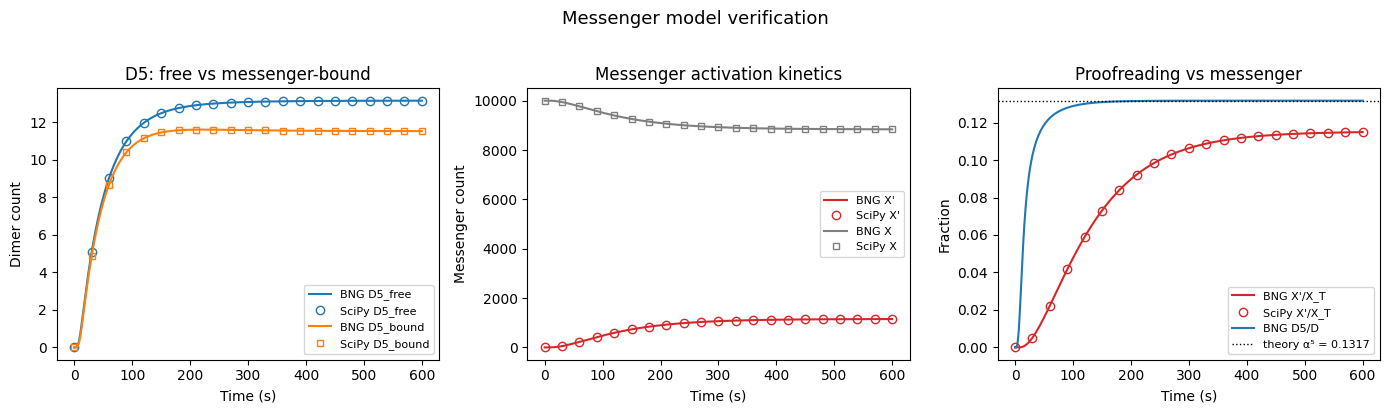

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
every = 15

# Panel 1: D5 free vs bound
ax = axes[0]
ax.plot(t_mbng, bng_m_D5f, "C0-", lw=1.5, label="BNG D5_free")
ax.plot(t_mbng[::every], sci_m_D5f[::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy D5_free")
ax.plot(t_mbng, bng_m_D5b, "C1-", lw=1.5, label="BNG D5_bound")
ax.plot(t_mbng[::every], sci_m_D5b[::every], "s", mfc="none",
        mec="C1", ms=5, label="SciPy D5_bound")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Dimer count")
ax.set_title("D5: free vs messenger-bound")
ax.legend(fontsize=8)

# Panel 2: messenger activation
ax = axes[1]
ax.plot(t_mbng, bng_m_Xon, "C3-", lw=1.5, label="BNG X'")
ax.plot(t_mbng[::every], sci_m_Xon[::every], "o", mfc="none",
        mec="C3", ms=6, label="SciPy X'")
ax.plot(t_mbng, bng_m_Xoff, "C7-", lw=1.5, label="BNG X")
ax.plot(t_mbng[::every], sci_m_Xoff[::every], "s", mfc="none",
        mec="C7", ms=5, label="SciPy X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Messenger count")
ax.set_title("Messenger activation kinetics")
ax.legend(fontsize=8)

# Panel 3: X_on/NX vs D5/D_total
ax = axes[2]
ax.plot(t_mbng, bng_m_Xon / NX, "C3-", lw=1.5,
        label="BNG X'/X_T")
ax.plot(t_mbng[::every], sci_m_Xon[::every] / NX, "o",
        mfc="none", mec="C3", ms=6, label="SciPy X'/X_T")
bng_m_frac = bng_m_D5 / np.maximum(bng_m_dimers, 1e-30)
ax.plot(t_mbng, bng_m_frac, "C0-", lw=1.5,
        label="BNG D5/D")
ax.axhline(alpha**N, color="k", ls=":", lw=1,
           label=f"theory α⁵ = {alpha**N:.4f}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fraction")
ax.set_title("Proofreading vs messenger")
ax.legend(fontsize=8)

fig.suptitle("Messenger model verification", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 4. Steady-state theory check (Eq. 13–17)

Verify the steady-state analytical predictions:
- **Base model:** D5/D = α⁵ (Eq. 14)
- **Messenger model:** X'/X_T from quadratic (Eq. 16–17)

In [9]:
# --- Base model: check D_i/D = alpha^i * (1-alpha) for i<N,
#     D_N/D = alpha^N  (Eq. 13-14) ---

ss_base = sol_base.y[:, -1]
D_ss = ss_base[3:9]
D_total_ss = D_ss.sum()

print("Base model — steady-state dimer distribution:")
print(f"{'State':>6}  {'BNG':>10}  {'SciPy':>10}  {'Theory':>10}")
for i in range(N):
    theory = alpha**i * (1 - alpha)
    bng_val = bng[-1, hdr.index(f"Obs_D{i}")] / bng_dimers[-1]
    sci_val = D_ss[i] / D_total_ss
    print(f"  D{i}/D  {bng_val:10.6f}  {sci_val:10.6f}  {theory:10.6f}")
theory_N = alpha**N
bng_val_N = bng[-1, hdr.index("Obs_D5")] / bng_dimers[-1]
sci_val_N = D_ss[N] / D_total_ss
print(f"  D{N}/D  {bng_val_N:10.6f}  {sci_val_N:10.6f}  {theory_N:10.6f}")

# --- Messenger model: check X'/X_T via Eq. 16-17 ---
ss_msg = sol_msg.y[:, -1]
D5f_ss, D5b_ss = ss_msg[8], ss_msg[9]
DJ_ss = D5f_ss + D5b_ss
Xon_ss = ss_msg[11]

# Km (Eq. below Eq. 12, with k-2 = koff)
Km = (2*koff + kcat + kx_off) / kx_on

# Solve quadratic (Eq. 17) for X/Km
a_coef = 1.0
b_coef = 1 - (1 - (1 + kcat/mu) * DJ_ss/NX) * NX/Km
c_coef = -NX / Km
disc = b_coef**2 - 4*a_coef*c_coef
X_over_Km = (-b_coef + np.sqrt(disc)) / (2*a_coef)

# X'/X_T (Eq. 16)
Xon_theory = (kcat/mu) * (X_over_Km/(1+X_over_Km)) * (DJ_ss/NX) * NX

print(f"\nMessenger model — steady-state messenger activation:")
print(f"  Km = {Km:.1f} molecules")
print(f"  DJ (D5 total) = {DJ_ss:.2f} (SciPy)")
print(f"  X'/X_T  BNG   = {bng_m_Xon[-1]/NX:.6f}")
print(f"  X'/X_T  SciPy = {Xon_ss/NX:.6f}")
print(f"  X'/X_T  Eq.16 = {Xon_theory/NX:.6f}")

Base model — steady-state dimer distribution:
 State         BNG       SciPy      Theory
  D0/D    0.333333    0.333333    0.333333
  D1/D    0.222222    0.222222    0.222222
  D2/D    0.148148    0.148148    0.148148
  D3/D    0.098765    0.098765    0.098765
  D4/D    0.065844    0.065844    0.065844
  D5/D    0.131687    0.131687    0.131687

Messenger model — steady-state messenger activation:
  Km = 10083.3 molecules
  DJ (D5 total) = 24.67 (SciPy)
  X'/X_T  BNG   = 0.114898
  X'/X_T  SciPy = 0.114876
  X'/X_T  Eq.16 = 0.115240


## 5. Summary figure (saved as PNG)

Saved: /Users/wish/Code/BNGL_library/models/kinetic_proofreading_hlavacek2001/verify_hlavacek2001.png


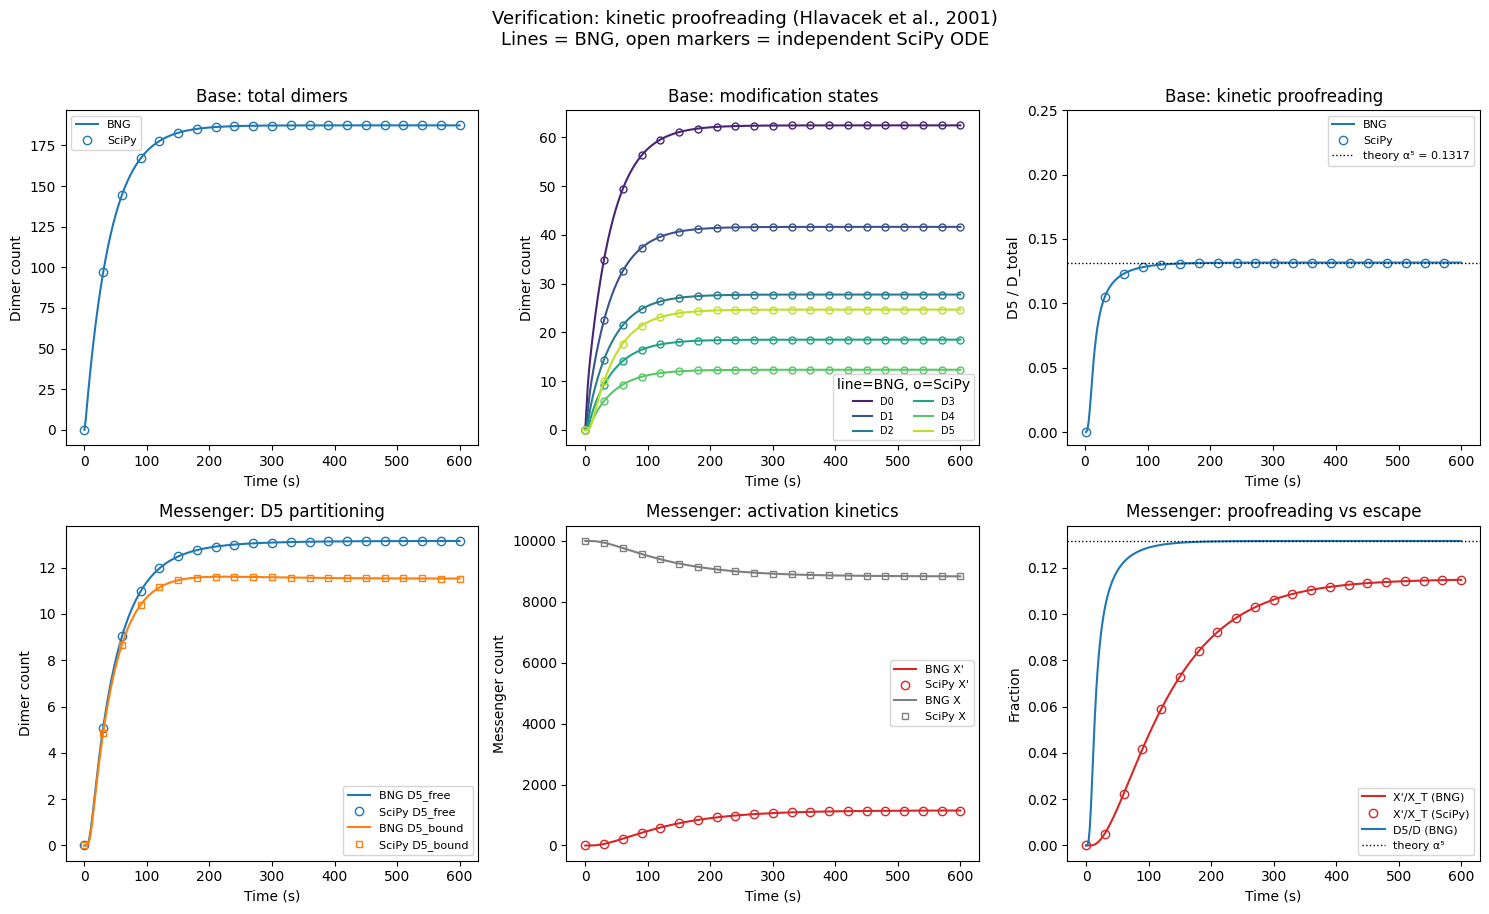

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
every = 15   # subsample SciPy for marker visibility

# === Row 1: Base model ===
ax = axes[0, 0]
ax.plot(t_bng, bng_dimers, "C0-", lw=1.5, label="BNG")
ax.plot(t_bng[::every], sci_dimers[::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Dimer count")
ax.set_title("Base: total dimers")
ax.legend(fontsize=8)

ax = axes[0, 1]
for i in range(6):
    bng_Di = bng[:, hdr.index(f"Obs_D{i}")]
    sci_Di = sol_base.sol(t_bng)[3 + i]
    ax.plot(t_bng, bng_Di, "-", color=colors_d[i], lw=1.5,
            label=f"D{i}")
    ax.plot(t_bng[::every], sci_Di[::every], "o", mfc="none",
            mec=colors_d[i], ms=5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Dimer count")
ax.set_title("Base: modification states")
ax.legend(fontsize=7, ncol=2, title="line=BNG, o=SciPy")

ax = axes[0, 2]
ax.plot(t_bng[1:], frac_bng[1:], "C0-", lw=1.5, label="BNG")
ax.plot(t_bng[1::every], frac_sci[1::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy")
ax.axhline(alpha**N, color="k", ls=":", lw=1,
           label=f"theory α⁵ = {alpha**N:.4f}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("D5 / D_total")
ax.set_title("Base: kinetic proofreading")
ax.set_ylim(-0.01, 0.25)
ax.legend(fontsize=8)

# === Row 2: Messenger model ===
ax = axes[1, 0]
ax.plot(t_mbng, bng_m_D5f, "C0-", lw=1.5, label="BNG D5_free")
ax.plot(t_mbng[::every], sci_m_D5f[::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy D5_free")
ax.plot(t_mbng, bng_m_D5b, "C1-", lw=1.5, label="BNG D5_bound")
ax.plot(t_mbng[::every], sci_m_D5b[::every], "s", mfc="none",
        mec="C1", ms=5, label="SciPy D5_bound")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Dimer count")
ax.set_title("Messenger: D5 partitioning")
ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(t_mbng, bng_m_Xon, "C3-", lw=1.5, label="BNG X'")
ax.plot(t_mbng[::every], sci_m_Xon[::every], "o", mfc="none",
        mec="C3", ms=6, label="SciPy X'")
ax.plot(t_mbng, bng_m_Xoff, "C7-", lw=1.5, label="BNG X")
ax.plot(t_mbng[::every], sci_m_Xoff[::every], "s", mfc="none",
        mec="C7", ms=5, label="SciPy X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Messenger count")
ax.set_title("Messenger: activation kinetics")
ax.legend(fontsize=8)

ax = axes[1, 2]
ax.plot(t_mbng, bng_m_Xon / NX, "C3-", lw=1.5,
        label="X'/X_T (BNG)")
ax.plot(t_mbng[::every], sci_m_Xon[::every] / NX, "o",
        mfc="none", mec="C3", ms=6, label="X'/X_T (SciPy)")
bng_m_frac2 = bng_m_D5 / np.maximum(bng_m_dimers, 1e-30)
ax.plot(t_mbng, bng_m_frac2, "C0-", lw=1.5, label="D5/D (BNG)")
ax.axhline(alpha**N, color="k", ls=":", lw=1, label=f"theory α⁵")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fraction")
ax.set_title("Messenger: proofreading vs escape")
ax.legend(fontsize=8)

fig.suptitle(
    "Verification: kinetic proofreading (Hlavacek et al., 2001)\n"
    "Lines = BNG, open markers = independent SciPy ODE",
    fontsize=13, y=1.01)
fig.tight_layout()

out_png = MODEL_DIR / "verify_hlavacek2001.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()

In [11]:
# Clean up temp directories
import shutil
shutil.rmtree("/tmp/verify_base", ignore_errors=True)
shutil.rmtree("/tmp/verify_msg", ignore_errors=True)
print("Temp files cleaned up.")

Temp files cleaned up.
